In [3]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn

  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------------------------------ --------- 7.3/9.8 MB 54.0 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 40.8 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.3 MB 51.3 MB/s eta 0:00:01
   ------ --------------------------------- 2.1/12.3 MB 4.4 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.3 MB 6.4 MB/s eta 0:00:02
   --------------------- ------------------ 6.6/12.3 MB 7.6 MB/s eta 0:00:01
   ------------------------------ --------- 9.4/12.3 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 9.7 MB/s  0:00:01
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

In [2]:
data=pd.read_csv('heart.csv')

In [3]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [13]:
num_observations,num_features=data.shape
print(num_observations)
print(num_features)

918
12


In [4]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


avg age =53.51 


In [5]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

no null values

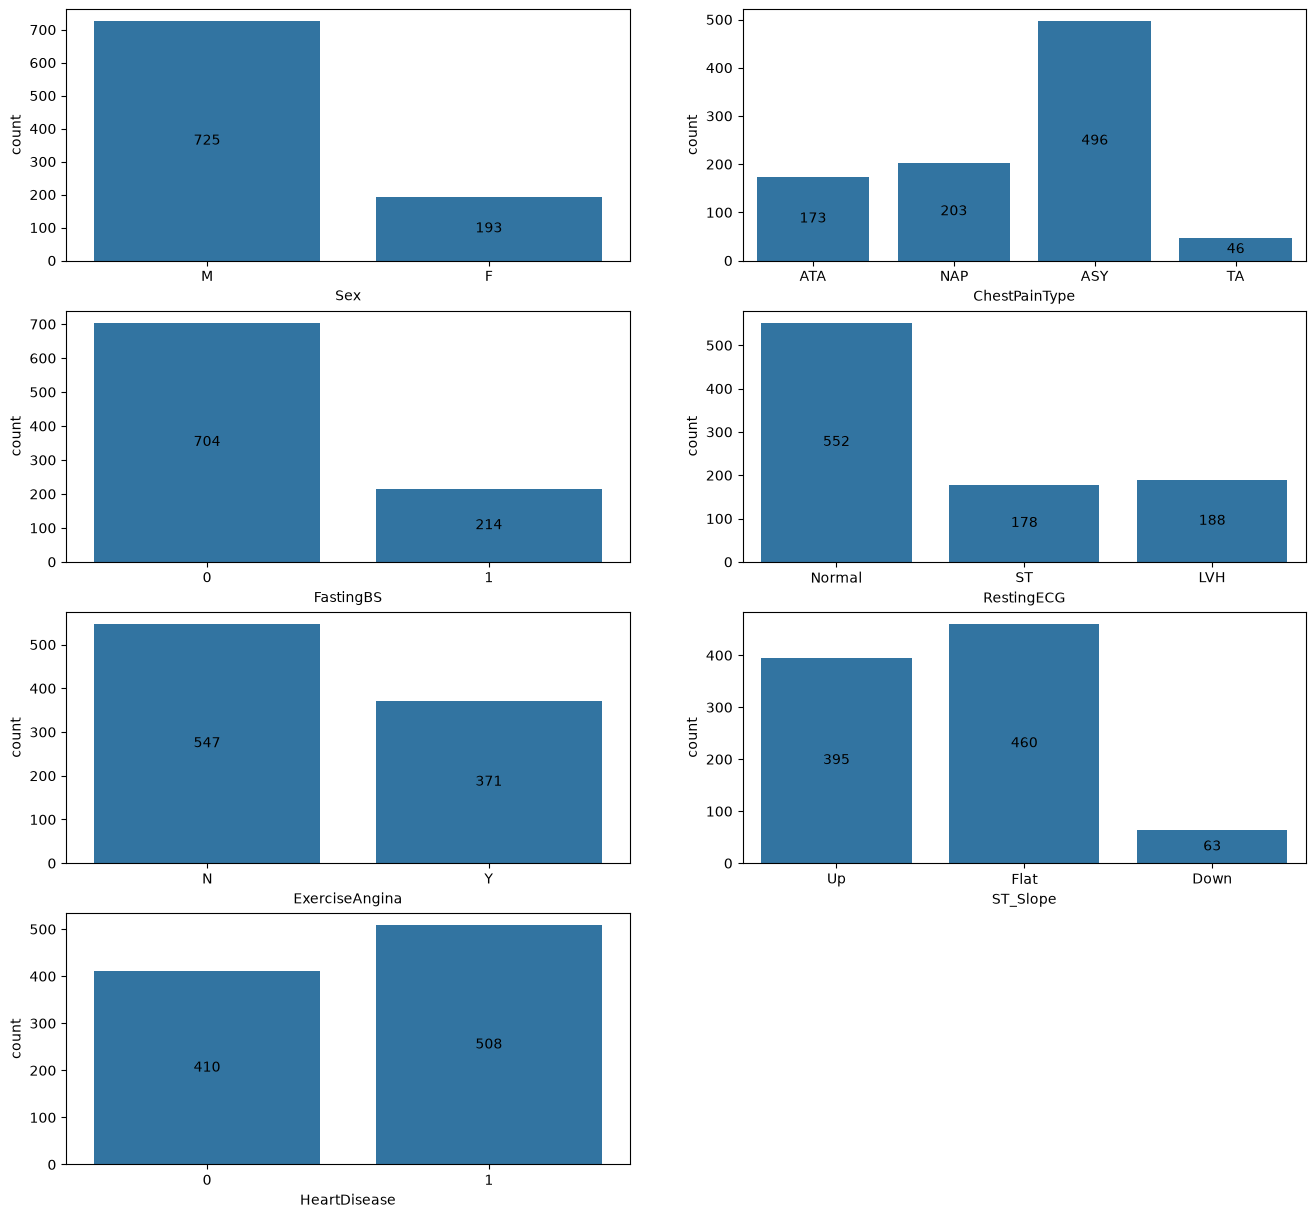

In [6]:
categorical_cols=["Sex","ChestPainType","FastingBS","RestingECG","ExerciseAngina","ST_Slope",'HeartDisease']
fig=plt.figure(figsize=(16,15))
for idx,cols in enumerate(categorical_cols):
    ax=plt.subplot(4,2,idx+1)
    sns.countplot(x=data[cols],ax=ax) #countplot counts occurrences.
    #adding data labels to each bar
    for containers in ax.containers: #After Seaborn creates the bars, ax.containers contains those bars.
        ax.bar_label(containers,label_type="center") #places label inside the bar

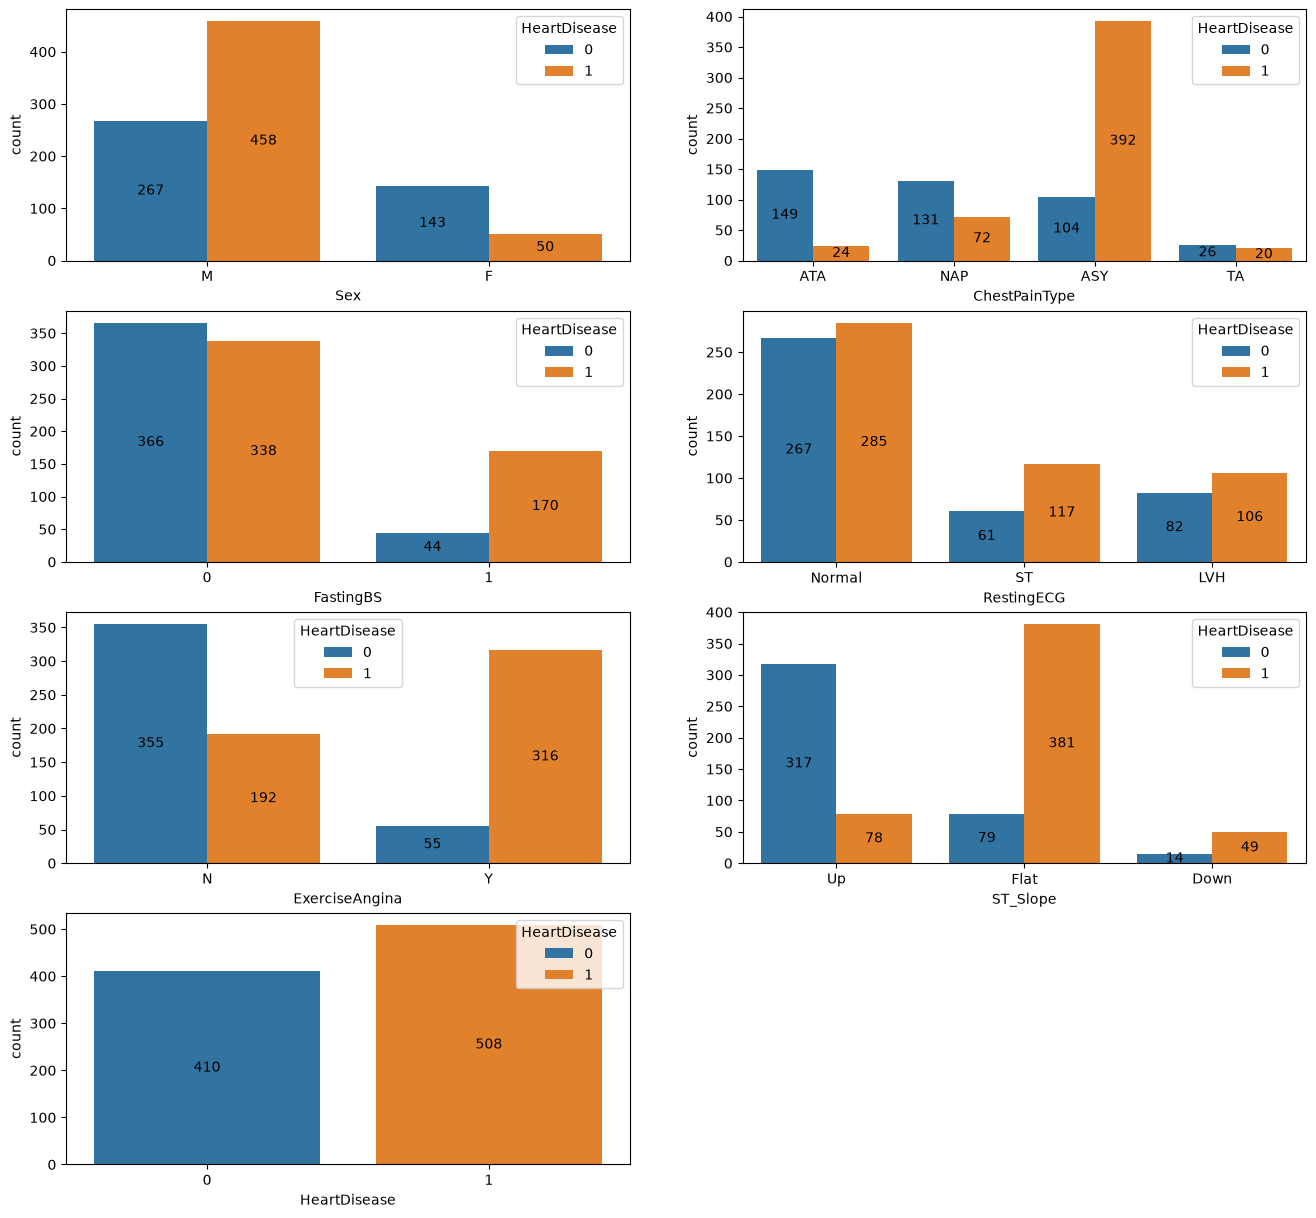

In [7]:
categorical_cols=["Sex","ChestPainType","FastingBS","RestingECG","ExerciseAngina","ST_Slope",'HeartDisease']
fig=plt.figure(figsize=(16,15))
for idx,cols in enumerate(categorical_cols):
    ax=plt.subplot(4,2,idx+1)
    #group by heart disease
    sns.countplot(x=data[cols],hue=data["HeartDisease"],ax=ax) #countplot counts occurrences.
    #adding data labels to each bar
    for containers in ax.containers: #After Seaborn creates the bars, ax.containers contains those bars.
        ax.bar_label(containers,label_type="center") #places label inside the bar

In [8]:
data[data["RestingBP"]==0].info()

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 449 to 449
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1 non-null      int64  
 1   Sex             1 non-null      str    
 2   ChestPainType   1 non-null      str    
 3   RestingBP       1 non-null      int64  
 4   Cholesterol     1 non-null      int64  
 5   FastingBS       1 non-null      int64  
 6   RestingECG      1 non-null      str    
 7   MaxHR           1 non-null      int64  
 8   ExerciseAngina  1 non-null      str    
 9   Oldpeak         1 non-null      float64
 10  ST_Slope        1 non-null      str    
 11  HeartDisease    1 non-null      int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 228.0 bytes


In [9]:
data[data["Cholesterol"]==0].info()

<class 'pandas.DataFrame'>
Index: 172 entries, 293 to 536
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             172 non-null    int64  
 1   Sex             172 non-null    str    
 2   ChestPainType   172 non-null    str    
 3   RestingBP       172 non-null    int64  
 4   Cholesterol     172 non-null    int64  
 5   FastingBS       172 non-null    int64  
 6   RestingECG      172 non-null    str    
 7   MaxHR           172 non-null    int64  
 8   ExerciseAngina  172 non-null    str    
 9   Oldpeak         172 non-null    float64
 10  ST_Slope        172 non-null    str    
 11  HeartDisease    172 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 17.5 KB


In [10]:
#Data Cleaning
df_clean=data.copy() #recommended to make a copy when cleaning data
df_clean=df_clean[df_clean["RestingBP"]!=0]
heartdisease_mask=df_clean["HeartDisease"]==0

Cholesterol_without_heartdisease=df_clean.loc[heartdisease_mask,"Cholesterol"]
Cholesterol_with_heartdisease=df_clean.loc[~heartdisease_mask,"Cholesterol"]

df_clean.loc[heartdisease_mask,'Cholesterol']=Cholesterol_without_heartdisease.replace(to_replace=0,value=Cholesterol_without_heartdisease.median())
df_clean.loc[~heartdisease_mask,'Cholesterol']=Cholesterol_with_heartdisease.replace(to_replace=0,value=Cholesterol_with_heartdisease.median())

In [30]:
df_clean[["Cholesterol","RestingBP"]].describe()

,Cholesterol,RestingBP
count,917.000000,917.000000
mean,239.700109,132.540894
std,54.352727,17.999749
min,85.000000,80.000000
25%,214.000000,120.000000
50%,225.000000,130.000000
75%,267.000000,140.000000
max,603.000000,200.000000


In [11]:
#converting categorical data to 0 and 1
df_clean=pd.get_dummies(df_clean,drop_first=True)
df_clean.head()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


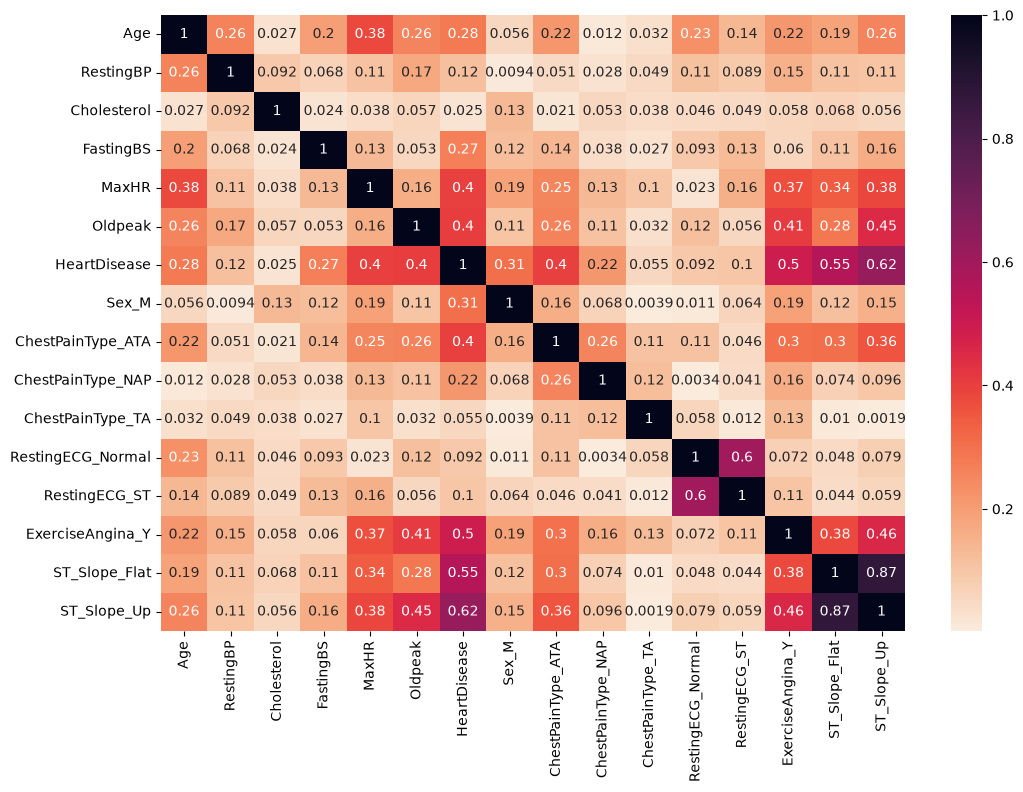

In [ ]:
correlation = abs(df_clean.corr())
plt.figure(figsize=(12,8))
sns.heatmap(correlation,annot=True,cmap="rocket_r") #rocket_r is color, we can choose any
plt.show()  # the brighter the colour the stronger the correlation



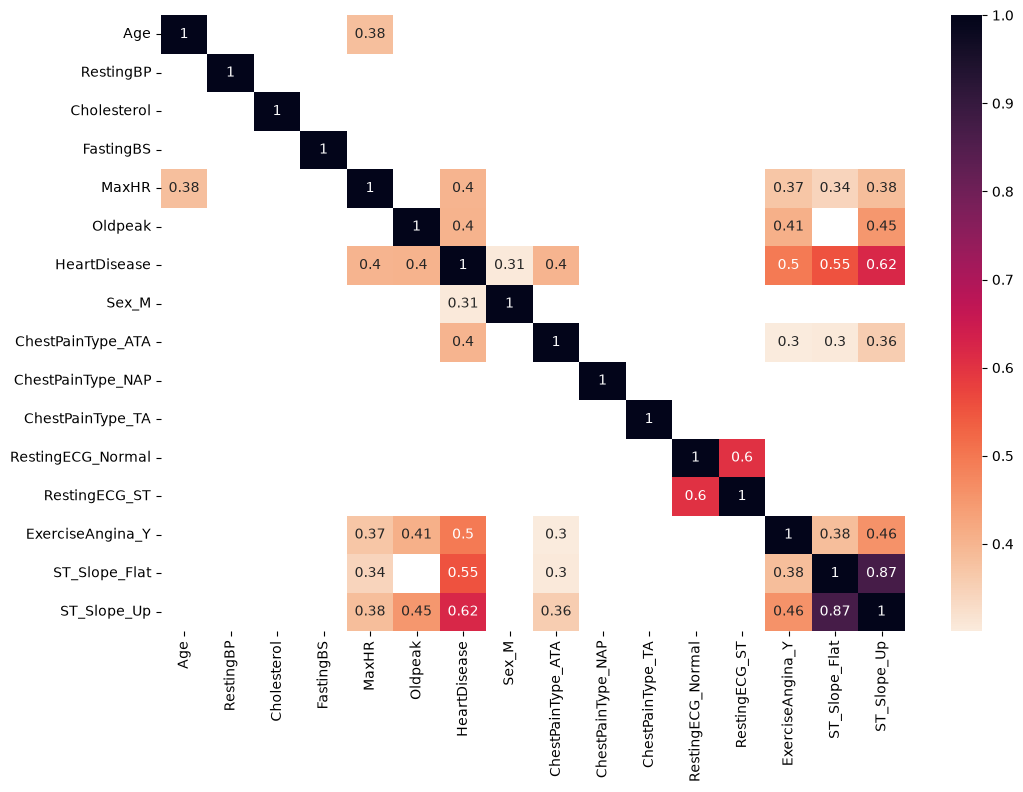

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(correlation[correlation>0.30],annot=True,cmap="rocket_r") #rocket_r is color, we can choose any
plt.show()  # the brighter the colour the stronger the correlation


In [16]:
#splitting and training test data
X=df_clean.drop(["HeartDisease"],axis=1)
y=df_clean["HeartDisease"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.15,random_state=417)

features=["MaxHR","Oldpeak","Sex_M","ExerciseAngina_Y","ST_Slope_Flat","ST_Slope_Up"]

for feature in features:
    knn= KNeighborsClassifier(n_neighbors = 3)
    knn.fit(X_train[[feature]],y_train)
    accuracy=knn.score(X_test[[feature]],y_test)
    print(f"The knn classifier trained on {feature} has an accuracy of {accuracy}")




The knn classifier trained on MaxHR has an accuracy of 0.5507246376811594
The knn classifier trained on Oldpeak has an accuracy of 0.5869565217391305
The knn classifier trained on Sex_M has an accuracy of 0.6159420289855072
The knn classifier trained on ExerciseAngina_Y has an accuracy of 0.7318840579710145
The knn classifier trained on ST_Slope_Flat has an accuracy of 0.8188405797101449
The knn classifier trained on ST_Slope_Up has an accuracy of 0.5507246376811594


In [19]:
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train[features])
X_test_scaled=scaler.fit_transform(X_test[features])
knn= KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train_scaled,y_train)
accuracy=knn.score(X_test_scaled,y_test)
print(f"accuracy: {accuracy *100:.2f}")

accuracy: 76.81


In [23]:
X=df_clean.drop(["HeartDisease"],axis=1)
y=df_clean["HeartDisease"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.15,random_state=417)
features=["MaxHR","Oldpeak","ExerciseAngina_Y","ST_Slope_Flat","ST_Slope_Up"] #removed sex_m to test whether this features hinders or improves accuracy

scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train[features])
X_train_scaled



array([[0.78169014, 0.42682927, 0.        , 0.        , 1.        ],
       [0.46478873, 0.42682927, 1.        , 1.        , 0.        ],
       [0.71126761, 0.48780488, 0.        , 1.        , 0.        ],
       ...,
       [0.26056338, 0.51219512, 1.        , 0.        , 1.        ],
       [0.15492958, 0.19512195, 0.        , 0.        , 1.        ],
       [0.59859155, 0.63414634, 0.        , 1.        , 0.        ]],
      shape=(779, 5))

In [27]:
grid_param={"n_neighbors":range(1,20),
            "metric": ["minkowski","manhattan"] }
knn=KNeighborsClassifier()
knn_grid=GridSearchCV(knn,grid_param,scoring='accuracy')
knn_grid.fit(X_train_scaled,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['minkowski', 'manhattan'], 'n_neighbors': range(1, 20)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of in

In [28]:
knn_grid.best_score_*100 ,knn_grid.best_params_

(np.float64(82.66749379652605), {'metric': 'manhattan', 'n_neighbors': 19})

In [29]:
X_test_scaled=scaler.transform(X_test[features])
predictions=knn_grid.best_estimator_.predict(X_test_scaled)
accuracy=accuracy_score(y_test,predictions)
print(f"accuracy on test set: {accuracy *100:.2f}")

accuracy on test set: 82.61


In [31]:
#checking data distribution since test was better than training results
print("Distribution of patients by their sex in the entire dataset")
print(X.Sex_M.value_counts())
print("\nDistribution of patients by their sex in the training dataset")
print(X_train.Sex_M.value_counts())

print("\nDistribution of patients by their sex in the test dataset")
print(X_test.Sex_M.value_counts())

Distribution of patients by their sex in the entire dataset
Sex_M
True     724
False    193
Name: count, dtype: int64

Distribution of patients by their sex in the training dataset
Sex_M
True     615
False    164
Name: count, dtype: int64

Distribution of patients by their sex in the test dataset
Sex_M
True     109
False     29
Name: count, dtype: int64


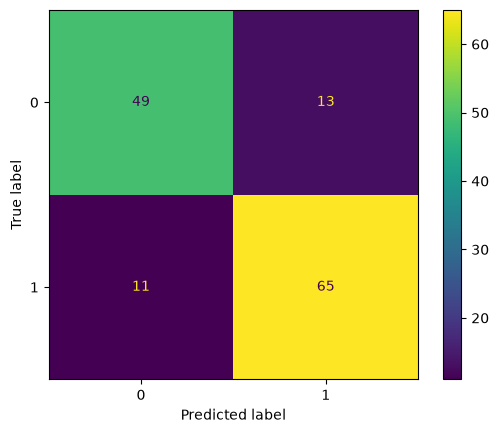

In [32]:
cf=confusion_matrix(y_test,predictions)
ConfusionMatrixDisplay(cf).plot()
plt.show()